# Amazon Fashion Reviews Sentiment Analysis & NLP Classification

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MSD-99/Amazon_Fashion_Sentiment_Analysis_NLP/blob/main/Amazon_Fashion_Sentiment_Analysis_NLP.ipynb)
![Python](https://img.shields.io/badge/Python-3.10%2B-blue?style=flat&logo=python&logoColor=white)
![NLP](https://img.shields.io/badge/NLP-Bag%20of%20Words%20%7C%20TF--IDF-green?style=flat)
![Scikit-Learn](https://img.shields.io/badge/scikit--learn-1.2%2B-F7931E?style=flat&logo=scikitlearn&logoColor=white)
![License](https://img.shields.io/badge/License-MIT-purple?style=flat)

---
**Dataset:** [Amazon Fashion Customer Reviews (UCSD Amazon Reviews 2023)](https://amazon-reviews-2023.github.io/)


## Required Libraries


In [ ]:
import os
import warnings
from datetime import datetime
from pathlib import Path
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix



## Loading the Dataset

In [4]:
# Load Amazon Fashion reviews using the datasets library

DATA_PATH = Path('src/data/amazon')

dataset = load_dataset("json", data_files=str(DATA_PATH / "Amazon_Fashion.jsonl"), split="train")
df_reviews = dataset.to_pandas()

print(f"Successfully loaded {len(df_reviews)} reviews.")
print(f"Columns: {df_reviews.columns.tolist()}")

# Convert timestamp to readable date
if 'timestamp' in df_reviews.columns:
    df_reviews['date'] = df_reviews['timestamp'].apply(lambda x: datetime.fromtimestamp(x/1000).strftime('%Y-%m-%d'))

print(f"DataFrame shape: {df_reviews.shape}")

Generating train split: 0 examples [00:00, ? examples/s]

Successfully loaded 2500939 reviews.
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
DataFrame shape: (2500939, 11)
DataFrame shape: (2500939, 11)


## Data Exploration and Quality Check

In [9]:
# Display basic information about the DataFrame
print("DataFrame Info:")
print("=" * 50)
print(df_reviews.info())
print("\n" + "=" * 50)
print("\nColumn Names:")
print(df_reviews.columns.tolist())
print("\n" + "=" * 50)
print("\nMissing Values:")
print(df_reviews.isnull().sum())
print("\n" + "=" * 50)
print("\nFirst 5 Reviews:")
df_reviews.head()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500939 entries, 0 to 2500938
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   rating             float64
 1   title              object 
 2   text               object 
 3   images             object 
 4   asin               object 
 5   parent_asin        object 
 6   user_id            object 
 7   timestamp          int64  
 8   helpful_vote       int64  
 9   verified_purchase  bool   
 10  date               object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 193.2+ MB
None


Column Names:
['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'date']


Missing Values:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verifi

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,date
0,5.0,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,1578528394489,3,True,2020-01-09
1,5.0,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1608426246701,0,True,2020-12-20
2,2.0,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,1432344828000,3,True,2015-05-23
3,1.0,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,1546289847095,2,True,2019-01-01
4,5.0,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1439476166000,0,True,2015-08-13


In [10]:
# Rating distribution analysis
print("Rating Distribution:")
print("=" * 50)
print(df_reviews['rating'].value_counts().sort_index())
print("\n" + "=" * 50)
print("\nRating Statistics:")
print(df_reviews['rating'].describe())
print("\n" + "=" * 50)
print(f"\nVerified Purchases: {df_reviews['verified_purchase'].sum()} out of {len(df_reviews)}")
print(f"Percentage: {df_reviews['verified_purchase'].mean() * 100:.2f}%")

Rating Distribution:
rating
1.0     303411
2.0     173462
3.0     245471
4.0     352327
5.0    1426268
Name: count, dtype: int64


Rating Statistics:
count    2.500939e+06
mean     3.969467e+00
std      1.427171e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


Verified Purchases: 2337702 out of 2500939
Percentage: 93.47%


## Sample Review Display

In [39]:
# Display sample reviews with full content
print("Sample Reviews (First 3):")
print("=" * 70)

for idx, row in df_reviews.head(3).iterrows():
    print(f"\n--- Review {idx + 1} ---")
    print(f"Rating: {'⭐' * int(row['rating']) if pd.notnull(row['rating']) else 'N/A'} ({row['rating']})")
    print(f"Title: {row['title'] if 'title' in row and pd.notnull(row['title']) else ''}")
    # Use reviewer_name if available, else user_id
    reviewer = row['reviewer_name'] if 'reviewer_name' in row and pd.notnull(row['reviewer_name']) else row.get('user_id', '')
    print(f"Reviewer: {reviewer}")
    print(f"Date: {row['date'] if 'date' in row and pd.notnull(row['date']) else ''}")
    print(f"Verified Purchase: {'Yes' if 'verified_purchase' in row and row['verified_purchase'] else 'No'}")
    print(f"Helpful Votes: {row['helpful_votes'] if 'helpful_votes' in row else row.get('helpful_vote', 0)}")
    # Use body if available, else text
    review_body = row['body'] if 'body' in row and pd.notnull(row['body']) else row.get('text', '')
    print(f"Review Body:\n{review_body[:500]}..." if len(str(review_body)) > 500 else f"Review Body:\n{review_body}")
    print("-" * 70)

Sample Reviews (First 3):

--- Review 1 ---
Rating: ⭐⭐⭐⭐⭐ (5.0)
Title: Pretty locket
Reviewer: AGBFYI2DDIKXC5Y4FARTYDTQBMFQ
Date: 2020-01-09
Verified Purchase: Yes
Helpful Votes: 3
Review Body:
I think this locket is really pretty. The inside back is a solid silver depression and the front is a dome that is not solid (knotted). You could use it to store a small photo, lock of hair, etc but I use it when I need to carry medication with me. Closes securely. High quality & very pretty.
----------------------------------------------------------------------

--- Review 2 ---
Rating: ⭐⭐⭐⭐⭐ (5.0)
Title: A
Reviewer: AFQLNQNQYFWQZPJQZS6V3NZU4QBQ
Date: 2020-12-20
Verified Purchase: Yes
Helpful Votes: 0
Review Body:
Great
----------------------------------------------------------------------

--- Review 3 ---
Rating: ⭐⭐ (2.0)
Title: Two Stars
Reviewer: AHITBJSS7KYUBVZPX7M2WJCOIVKQ
Date: 2015-05-23
Verified Purchase: Yes
Helpful Votes: 3
Review Body:
One of the stones fell out within the first 2 w

## Data Preprocessing and Cleaning

In [43]:
# 1. Count reviews per product (parent_asin)
product_counts = df_reviews['parent_asin'].value_counts()

# 2. Get the product ID with the most reviews
top_product_id = product_counts.index[0]
review_count = product_counts.iloc[0]

print(f"Selected Product ID: {top_product_id}")
print(f"Total Reviews for this product: {review_count}")

# Filter the dataset to keep only this product's reviews
df_product = df_reviews[df_reviews['parent_asin'] == top_product_id].copy()

# 4. Keep exactly 250 reviews (random sample)
if len(df_product) > 250:
    df_product = df_product.sample(n=250, random_state=42)

print(f"Final dataset shape for training: {df_product.shape}")

Selected Product ID: B09TXZHKLG
Total Reviews for this product: 7554
Final dataset shape for training: (250, 11)


## Create Labels (Positive/Neutral.Negative)

In [44]:
def define_sentiment(rating):
    if rating <= 2:
        return 'NEGATIVE'
    elif rating == 3:
        return 'NEUTRAL'
    else:
        return 'POSITIVE'

df_product['sentiment'] = df_product['rating'].apply(define_sentiment)

In [45]:
print(f"Selected Product: {top_product_id}")
print("Sentiment Distribution:")
print(df_product['sentiment'].value_counts())

# Show the first few rows to verify
print(df_product[['rating', 'sentiment', 'text']].head())

Selected Product: B09TXZHKLG
Sentiment Distribution:
sentiment
POSITIVE    217
NEGATIVE     17
NEUTRAL      16
Name: count, dtype: int64
         rating sentiment                                               text
1705902     5.0  POSITIVE  Love this watch. Exactly what I was looking fo...
2192160     5.0  POSITIVE                             My son loves the watch
2382626     5.0  POSITIVE  Purchased for a lifeguarding/camp counselor jo...
462110      3.0   NEUTRAL                                  Too big for women
2239321     5.0  POSITIVE  super light-weight and perfect for wearing wit...


Since we have imbalanced classes, we could not continue with this approach because most of the reviews are positive (217). So, we will find a product with more balanced reviews in the next steps.

In [49]:
# Apply sentiment to the whole dataset first (or a large chunk of it)
df_reviews['sentiment'] = df_reviews['rating'].apply(define_sentiment)

# Count Positive and Negative reviews per product
product_sentiment_counts = df_reviews.groupby(['parent_asin', 'sentiment']).size().unstack(fill_value=0)

# Filter: Find a product with at least 75 positive and 75 negative reviews
balanced_candidates = product_sentiment_counts[
    (product_sentiment_counts['POSITIVE'] >= 125) & 
    (product_sentiment_counts['NEGATIVE'] >= 125)
]

print(f"Found {len(balanced_candidates)} products with balanced reviews.")

if len(balanced_candidates) > 0:
    # Pick the one with the most total reviews just to be safe
    best_product_id = balanced_candidates.sum(axis=1).idxmax()
    print(f"Best Product ID: {best_product_id}")
    print("Counts for this product:")
    print(balanced_candidates.loc[best_product_id])
else:
    print("No single product has +75 negative reviews.")

Found 48 products with balanced reviews.
Best Product ID: B09TXZHKLG
Counts for this product:
sentiment
NEGATIVE     698
NEUTRAL      479
POSITIVE    6377
Name: B09TXZHKLG, dtype: int64


## Build the Balanced Dataset

In [50]:
df_chosen = df_reviews[df_reviews['parent_asin'] == best_product_id].copy()

# Separate positive and negative reviews
df_pos = df_chosen[df_chosen['sentiment'] == 'POSITIVE']
df_neg = df_chosen[df_chosen['sentiment'] == 'NEGATIVE']

# Sample exactly 125 of each
df_balanced = pd.concat([
    df_pos.sample(n=125, random_state=42),
    df_neg.sample(n=125, random_state=42)
])

# Shuffle the balanced dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset shape: {df_balanced.shape}")
print("Sentiment Distribution in Balanced Dataset:")
print(df_balanced['sentiment'].value_counts())

Balanced dataset shape: (250, 12)
Sentiment Distribution in Balanced Dataset:
sentiment
NEGATIVE    125
POSITIVE    125
Name: count, dtype: int64


## Bag of Words (Count Vectorization)

In [52]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Define inputs (X) and targets (y)
X_text = df_balanced['text']
y = df_balanced['sentiment']

# Initialize the Vectorizer
# stop_words='english' removes common words like "the", "is", "and" which don't carry sentiment
vectorizer = CountVectorizer(stop_words='english')

# Fit and Transform
X_bow = vectorizer.fit_transform(X_text)

# Split into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_bow, y, test_size=0.2, random_state=42
)


print(f"Matrix Shape: {X_bow.shape}")

Matrix Shape: (250, 1221)


# Train Models

SVM, Decision Tree, and Logistic Regression

In [53]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

--- Model Performance Comparison ---

🔹 Evaluating: Logistic Regression (LR)
              precision    recall  f1-score   support

    NEGATIVE       0.85      0.81      0.83        27
    POSITIVE       0.79      0.83      0.81        23

    accuracy                           0.82        50
   macro avg       0.82      0.82      0.82        50
weighted avg       0.82      0.82      0.82        50



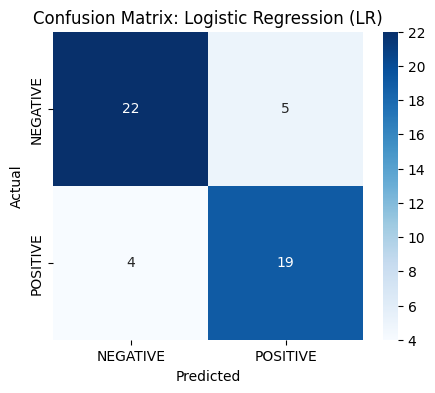


🔹 Evaluating: Support Vector Machine (SVM)
              precision    recall  f1-score   support

    NEGATIVE       0.81      0.81      0.81        27
    POSITIVE       0.78      0.78      0.78        23

    accuracy                           0.80        50
   macro avg       0.80      0.80      0.80        50
weighted avg       0.80      0.80      0.80        50



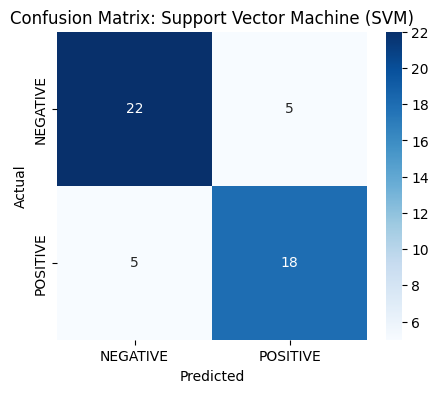


🔹 Evaluating: Decision Tree (DT)
              precision    recall  f1-score   support

    NEGATIVE       0.77      0.74      0.75        27
    POSITIVE       0.71      0.74      0.72        23

    accuracy                           0.74        50
   macro avg       0.74      0.74      0.74        50
weighted avg       0.74      0.74      0.74        50



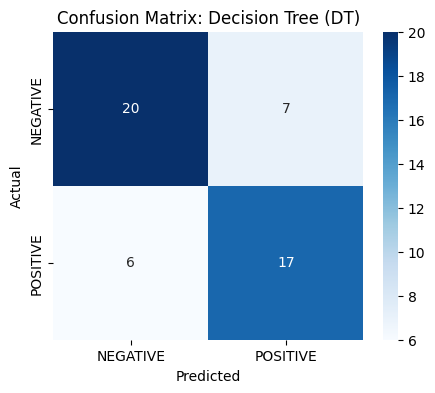

In [ ]:
# 1. Initialize the models
models = {
    "Logistic Regression (LR)": LogisticRegression(max_iter=1000),
    "Support Vector Machine (SVM)": SVC(kernel='linear'), # Linear kernel is often better for text
    "Decision Tree (DT)": DecisionTreeClassifier()
}

# 2. Train and Evaluate
print("--- Model Performance Comparison ---")

for name, model in models.items():
    print(f"\n🔹 Evaluating: {name}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Classification report
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

In [58]:
log_reg = models["Logistic Regression (LR)"]
feature_names = vectorizer.get_feature_names_out()
coefs = log_reg.coef_[0]

# Create a dataframe of words and their weights
word_importance = pd.DataFrame({'word': feature_names, 'weight': coefs})
word_importance = word_importance.sort_values(by='weight')

print("Top 5 'Negative' Words (Lowest Weights):")
print(word_importance.head(5))
print("\nTop 5 'Positive' Words (Highest Weights):")
print(word_importance.tail(5))

Top 5 'Negative' Words (Lowest Weights):
        word    weight
976    small -1.526048
977  smaller -0.955332
113     band -0.908606
664      man -0.827696
777  pequeño -0.772099

Top 5 'Positive' Words (Highest Weights):
         word    weight
484      good  0.791426
1138       ve  0.933389
778   perfect  1.078816
490     great  1.113682
651      love  1.231841


# 2.11 Grid Search for Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Hyperparameters to test
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

# Metrics
# Macro vs Micro:
# Macro: Calculate metrics for each label, and find their unweighted mean. This does not take label imbalance into account.
# Micro: Aggregate the contributions of all classes to compute the average metric
scoring_metrics = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'F1': 'f1_macro'
}


# Grid Search
grid_search = GridSearchCV(
    LogisticRegression(max_iter=2000), 
    param_grid, 
    cv=5,                 # 5-fold Cross Validation
    scoring=scoring_metrics,
    refit='F1'            # Optimize for F1 score
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Display Results "At Each Step"
results = pd.DataFrame(grid_search.cv_results_)

# Clean up the table to show just the relevant columns
columns_to_show = [
    'param_C', 'param_solver', 
    'mean_test_Accuracy', 
    'mean_test_Precision', 
    'mean_test_Recall', 
    'mean_test_F1'
]
print("\n--- Grid Search Results ---")
print(results[columns_to_show].sort_values(by='mean_test_F1', ascending=False))

# Final Evaluation
best_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

print("\n--- Final Test Set Performance (Best Model) ---")
y_pred_optimized = best_model.predict(X_test)
print(classification_report(y_test, y_pred_optimized))


--- Grid Search Results ---
   param_C param_solver  mean_test_Accuracy  mean_test_Precision  \
6    100.0    liblinear               0.820             0.824163   
7    100.0        lbfgs               0.815             0.817742   
4     10.0    liblinear               0.810             0.812604   
5     10.0        lbfgs               0.805             0.807717   
2      1.0    liblinear               0.800             0.806248   
0      0.1    liblinear               0.795             0.801045   
3      1.0        lbfgs               0.795             0.802026   
1      0.1        lbfgs               0.790             0.796893   

   mean_test_Recall  mean_test_F1  
6          0.820564      0.819572  
7          0.815564      0.814677  
4          0.810564      0.809705  
5          0.805564      0.804671  
2          0.801090      0.798880  
0          0.796090      0.793792  
3          0.795827      0.793777  
1          0.790852      0.788020  

Best Parameters: {'C': 100, 'solv